# TP - Optimiser la Random Forest avec Optuna et tracer les essais dans MLflow

## Objectif concret et point de départ

Ce notebook reprend l'exercice complet avec une nouvelle méthode : **Optuna**. Il produit une campagne indépendante du Random Search et répond à la question : une recherche adaptative améliore-t-elle la Random Forest de référence sur une période future ?

Une **machine-heure** est l'état d'une machine pendant une heure. La cible vaut 1 lorsqu'une panne surviendra dans les 24 heures suivantes. Plusieurs lignes positives peuvent donc correspondre à la même panne.

**Prérequis observables :** le CSV Gold est présent, les splits `train`, `validation` et `test` existent, l'environnement `.venv` contient Optuna et MLflow. La Random Forest est la famille de modèles retenue dans les travaux précédents ; aucun arbre déjà entraîné n'est réutilisé.

**Livrables de cette exécution :** résultats Optuna complets, modèles rechargeables, matrice de confusion, fichiers de synthèse et nouvelle expérience MLflow `indusense-optuna-pedagogique`.

### Liens avec le cours

- `09_Optimisation.pdf`, pages 4 à 10 : espace plausible, validation croisée, Grid Search, Random Search et Optuna ;
- transcription du cours vers 38:18-40:59 : sauvegarder les essais et ne pas utiliser le test pendant l'optimisation ;
- transcription vers 54:10-55:29 : resserrer les plages sur des valeurs plausibles.


In [1]:
from pathlib import Path
import os
import sys
import json
import hashlib
import logging
import warnings
from time import perf_counter
from importlib.metadata import version

os.environ['MLFLOW_DISABLE_AGENT_HINT'] = '1'
for logger_name in ('mlflow', 'mlflow.sklearn', 'mlflow.utils.environment', 'mlflow.utils.uv_utils'):
    logging.getLogger(logger_name).setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'Hint: Inferred schema contains integer column.*',
                        category=UserWarning, module=r'mlflow\.types\.utils')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import mlflow
import mlflow.sklearn
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, fbeta_score)

optuna.logging.set_verbosity(optuna.logging.WARNING)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
STORE = ROOT / '.mlflow'
STORE.mkdir(exist_ok=True)
ARTIFACTS = STORE / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
mlflow.set_tracking_uri('sqlite:///' + (STORE / 'mlflow.db').as_posix())
EXPERIMENT = 'indusense-optuna-pedagogique'
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=ARTIFACTS.as_uri())
experiment = mlflow.set_experiment(EXPERIMENT)
mlflow.sklearn.autolog(disable=True)
versions = {p: version(p) for p in ['optuna', 'mlflow', 'scikit-learn', 'pandas', 'numpy']}

display(pd.DataFrame({'Composant': list(versions) + ['Expérience MLflow'],
                      'Valeur': list(versions.values()) + [EXPERIMENT]}))
print('OPTUNA_ET_MLFLOW_PRETS : les essais seront stockés dans SQLite et MLflow.')

,Composant,Valeur
0,optuna,5.0.0
1,mlflow,3.16.0
2,scikit-learn,1.9.1
3,pandas,3.0.5
4,numpy,2.5.2
5,Expérience MLflow,indusense-optuna-pedagogique


OPTUNA_ET_MLFLOW_PRETS : les essais seront stockés dans SQLite et MLflow.


## 1. Charger les données et protéger les frontières temporelles

Les trois jeux conservent leurs rôles :

- **train** : apprentissage et trois folds de validation croisée ;
- **validation dédiée** : choix du seuil F2 après la sélection des hyperparamètres ;
- **test** : comparaison finale uniquement après le gel du modèle et du seuil.

La cible regarde 24 heures dans le futur. Nous retirons donc les 24 dernières heures aux frontières du train et de la validation. Cette **purge** empêche un label situé juste avant une frontière de dépendre de la période suivante.


In [2]:
DATA = ROOT / 'datas/gold_dataset_20260622-080603.csv'
gold = pd.read_csv(DATA, parse_dates=['window_start', 'window_end'])
gold = gold.sort_values(['window_end', 'machine_id_std'], kind='stable').reset_index(drop=True)
TARGET = 'label_failure_next_24h'
assert not gold.duplicated(['machine_id_std', 'window_end']).any()
assert gold['window_end'].notna().all()
assert gold[TARGET].notna().all() and set(gold[TARGET].unique()) <= {0, 1, False, True}
assert set(gold.split_set.unique()) == {'train', 'validation', 'test'}
assert (gold.window_end - gold.window_start).eq(pd.Timedelta(hours=1)).all()

excluded = [c for c in gold if c.startswith(('label_failure_next_', 'future_incident_count_'))]
excluded += ['machine_id_std', 'window_start', 'window_end', 'split_set']
features = [c for c in gold if c not in excluded]
assert not gold[features].select_dtypes(exclude=['number', 'bool']).columns.tolist()

parts = {s: gold.loc[gold.split_set.eq(s)].copy() for s in ['train', 'validation', 'test']}
GAP = pd.Timedelta(hours=24)
purged = {}
for left, right in [('train', 'validation'), ('validation', 'test')]:
    before = len(parts[left])
    parts[left] = parts[left].loc[parts[left].window_end < parts[right].window_end.min() - GAP].copy()
    purged[left] = before - len(parts[left])
    assert parts[left].window_end.max() + GAP < parts[right].window_end.min()

X = {s: d[features].reset_index(drop=True) for s, d in parts.items()}
y = {s: d[TARGET].astype(int).reset_index(drop=True) for s, d in parts.items()}
assert all(v.nunique() == 2 for v in y.values())
DATA_SHA256 = hashlib.sha256(DATA.read_bytes()).hexdigest()

audit_rows = []
for split, frame in parts.items():
    audit_rows.append({'Jeu': split, 'Machine-heures': len(frame), 'Positives': int(y[split].sum()),
                       'Taux positif': y[split].mean(), 'Début': frame.window_end.min(),
                       'Fin': frame.window_end.max(), 'Valeurs manquantes': int(X[split].isna().sum().sum())})
display(pd.DataFrame(audit_rows).style.hide(axis='index').format({'Taux positif': '{:.2%}'}))
print(f'{len(gold)} lignes source, {gold.machine_id_std.nunique()} machines, {len(features)} variables.')
print(f'Purge : {purged["train"]} lignes du train et {purged["validation"]} lignes de la validation.')
print('Empreinte SHA-256 :', DATA_SHA256)

Jeu,Machine-heures,Positives,Taux positif,Début,Fin,Valeurs manquantes
train,93630,15545,16.60%,2025-06-01 01:00:00,2026-02-16 02:00:00,184390
validation,19785,3404,17.20%,2026-02-17 03:00:00,2026-04-13 01:00:00,37215
test,20145,3478,17.26%,2026-04-14 02:00:00,2026-06-09 00:00:00,37739


134280 lignes source, 15 machines, 88 variables.
Purge : 360 lignes du train et 360 lignes de la validation.
Empreinte SHA-256 : 2c6ee2408d6c764e57d7c7bacf17dc755954ca7b244a274363f07bf351203eee


## 2. Choisir Optuna et définir l'espace de recherche

### Principe

Une **study** Optuna regroupe des **trials**, c'est-à-dire des configurations évaluées. La fonction objectif retourne l'Average Precision moyenne des trois folds. Le `TPESampler` (*Tree-structured Parzen Estimator*) commence par cinq essais exploratoires, puis compare les zones associées aux meilleurs et moins bons scores afin de proposer quinze essais guidés.

### Comparaison avec les deux autres méthodes

| Méthode | Choix des configurations | Avantage | Limite dans ce TP |
|---|---|---|---|
| Grid Search | Toutes les combinaisons définies | Exhaustif dans la grille | Explosion combinatoire et valeurs continues discrétisées |
| Random Search | Tirages indépendants | Budget fixe, simple et robuste | N'apprend rien des essais précédents |
| **Optuna avec TPE** | Suggestions adaptées à l'historique | Concentre progressivement le budget dans les zones prometteuses | Dépendance supplémentaire, résultat dépendant du budget et du sampler |

Optuna convient ici parce que cinq hyperparamètres forment un espace beaucoup plus grand que la grille précédente. Le budget est fixé à **20 trials** : assez pour illustrer cinq démarrages aléatoires puis quinze propositions guidées, sans prétendre trouver l'optimum global.

Le **pruning** n'est pas activé. Une Random Forest scikit-learn est entraînée par un seul `fit` et les trois folds correspondent à des périodes différentes : interrompre un trial sur un premier fold faible rendrait la comparaison temporelle moins fiable.

### Espace plausible

| Hyperparamètre | Plage | Influence attendue |
|---|---|---|
| `n_estimators` | 100 à 500, pas de 50 | Stabilité contre coût de calcul |
| `max_depth` | 4 à 20 | Complexité et risque de surapprentissage |
| `min_samples_leaf` | 2 à 30, échelle logarithmique | Lissage des règles terminales |
| `min_samples_split` | 2 à 20, échelle logarithmique | Facilité à créer de nouvelles branches |
| `max_features` | `sqrt`, 15 %, 25 %, 35 %, 50 % | Diversité des arbres et coût de chaque séparation |


In [3]:
SEED, N_TRIALS, N_FOLDS = 42, 20, 3
N_STARTUP_TRIALS = 5
BASELINE_PARAMS = dict(n_estimators=300, max_depth=12, min_samples_leaf=5,
                       min_samples_split=2, max_features='sqrt')
MAX_FEATURE_CHOICES = ['sqrt', '15%', '25%', '35%', '50%']

def decode_params(sampled):
    params = dict(sampled)
    choice = params.pop('max_features_choice')
    params['max_features'] = 'sqrt' if choice == 'sqrt' else float(choice.rstrip('%')) / 100
    return params

def suggest_params(trial):
    sampled = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 30, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, log=True),
        'max_features_choice': trial.suggest_categorical('max_features_choice', MAX_FEATURE_CHOICES),
    }
    return sampled, decode_params(sampled)

timestamps = parts['train'].window_end.reset_index(drop=True)
blocks = np.array_split(np.sort(timestamps.unique()), N_FOLDS + 1)
folds, fold_metadata = [], []
for i in range(N_FOLDS):
    dates_val = blocks[i + 1]
    start = pd.Timestamp(dates_val[0])
    tr = np.flatnonzero((timestamps < start - GAP).to_numpy())
    va = np.flatnonzero(timestamps.isin(dates_val).to_numpy())
    assert len(tr) and len(va)
    assert timestamps.iloc[tr].max() + GAP < timestamps.iloc[va].min()
    assert not set(timestamps.iloc[tr]) & set(timestamps.iloc[va])
    assert y['train'].iloc[tr].nunique() == y['train'].iloc[va].nunique() == 2
    folds.append((tr, va))
    fold_metadata.append({'fold': i + 1, 'train_rows': len(tr), 'validation_rows': len(va),
                          'train_end': str(timestamps.iloc[tr].max()),
                          'validation_start': str(timestamps.iloc[va].min()),
                          'validation_end': str(timestamps.iloc[va].max())})

display(pd.DataFrame(fold_metadata).style.hide(axis='index'))
print(f'Budget principal : {N_TRIALS} trials x {N_FOLDS} folds = {N_TRIALS*N_FOLDS} fits CV.')
print('Cinq essais de démarrage explorent ; les quinze suivants sont guidés par TPE.')

fold,train_rows,validation_rows,train_end,validation_start,validation_end
1,23055,23415,2025-08-04 01:00:00,2025-08-05 02:00:00,2025-10-09 02:00:00
2,46470,23400,2025-10-08 02:00:00,2025-10-09 03:00:00,2025-12-13 02:00:00
3,69870,23400,2025-12-12 02:00:00,2025-12-13 03:00:00,2026-02-16 02:00:00


Budget principal : 20 trials x 3 folds = 60 fits CV.
Cinq essais de démarrage explorent ; les quinze suivants sont guidés par TPE.


## 3. Lancer les trials et tracer chaque essai

Pour chaque trial, le pipeline apprend l'imputation médiane et la forêt séparément dans chaque fold. MLflow enregistre les hyperparamètres, les trois scores, la moyenne, la dispersion, l'écart train-CV, les durées et le modèle réentraîné sur tout le train.

L'**écart train-CV** est l'AP moyenne sur les données apprises moins l'AP moyenne sur les validations. Un grand écart signale un risque de surapprentissage, mais un petit écart ne prouve pas que le modèle généralisera à toutes les périodes futures.

Les sorties restent synthétiques ; les journaux détaillés sont conservés dans la nouvelle expérience MLflow.


In [4]:
def pipeline(params):
    return Pipeline([
        ('imputation', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(**params, random_state=SEED,
             class_weight='balanced_subsample', bootstrap=True, n_jobs=-1)),
    ])

def evaluate_and_log(params, logged_params, role, run_name, parent_id):
    with mlflow.start_run(run_name=run_name, parent_run_id=parent_id, nested=True) as run:
        mlflow.set_tag('role', role)
        mlflow.log_params(logged_params)
        mlflow.log_params({'seed': SEED, 'folds': N_FOLDS, 'gap_hours': 24,
                           'class_weight': 'balanced_subsample', 'bootstrap': True})
        scores, train_scores = [], []
        start = perf_counter()
        for fold_number, (tr, va) in enumerate(folds, 1):
            fitted = pipeline(params).fit(X['train'].iloc[tr], y['train'].iloc[tr])
            val_score = average_precision_score(
                y['train'].iloc[va], fitted.predict_proba(X['train'].iloc[va])[:, 1])
            train_score = average_precision_score(
                y['train'].iloc[tr], fitted.predict_proba(X['train'].iloc[tr])[:, 1])
            scores.append(float(val_score)); train_scores.append(float(train_score))
            mlflow.log_metrics({f'fold_{fold_number}_ap': val_score,
                                f'fold_{fold_number}_train_ap': train_score})
        cv_seconds = perf_counter() - start
        metrics = {'cv_ap': float(np.mean(scores)), 'cv_std': float(np.std(scores)),
                   'train_ap': float(np.mean(train_scores)), 'cv_seconds': cv_seconds}
        metrics['gap_ap'] = metrics['train_ap'] - metrics['cv_ap']
        start = perf_counter()
        model = pipeline(params).fit(X['train'], y['train'])
        metrics['refit_seconds'] = perf_counter() - start
        mlflow.log_metrics(metrics)
        signature = mlflow.models.infer_signature(X['train'], model.predict(X['train'].iloc[:5]))
        model_info = mlflow.sklearn.log_model(
            model, name='modele', signature=signature, serialization_format='cloudpickle',
            pip_requirements=[f'{p}=={versions[p]}' for p in ['scikit-learn', 'pandas', 'numpy']]
                             + [f'cloudpickle=={version("cloudpickle")}'])
        return dict(params=params.copy(), sampled_params=logged_params.copy(), scores=scores,
                    train_scores=train_scores, **metrics, run_id=run.info.run_id,
                    model_uri=model_info.model_uri)

OPTUNA_STORAGE = 'sqlite:///' + (STORE / 'optuna.db').as_posix()
STUDY_NAME = 'indusense-optuna-tpe-20-v1'
sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP_TRIALS)
study = optuna.create_study(study_name=STUDY_NAME, storage=OPTUNA_STORAGE,
    direction='maximize', sampler=sampler, pruner=optuna.pruners.NopPruner(), load_if_exists=True)

existing_parent = study.user_attrs.get('mlflow_parent_run_id')
run_context = mlflow.start_run(run_id=existing_parent) if existing_parent else mlflow.start_run(
    run_name='optuna-tpe-20-essais')
campaign_started = perf_counter()

with run_context as parent:
    PARENT_ID = parent.info.run_id
    if not existing_parent:
        study.set_user_attr('mlflow_parent_run_id', PARENT_ID)
    mlflow.set_tags({'role': 'campagne', 'optimizer': 'optuna_tpe',
                     'test_status': 'historique_deja_consulte'})
    mlflow.log_params({'n_trials': N_TRIALS, 'n_startup_trials': N_STARTUP_TRIALS,
                       'n_folds': N_FOLDS, 'metric': 'average_precision', 'seed': SEED,
                       'pruner': 'NopPruner', 'dataset_sha256': DATA_SHA256})
    mlflow.log_dict({'versions': versions, 'folds': fold_metadata, 'features': features,
                     'excluded': excluded, 'study_name': STUDY_NAME}, 'protocole.json')

    if 'baseline_result' in study.user_attrs:
        baseline = json.loads(study.user_attrs['baseline_result'])
    else:
        baseline = evaluate_and_log(BASELINE_PARAMS, BASELINE_PARAMS, 'reference',
                                    'reference-manuelle', PARENT_ID)
        study.set_user_attr('baseline_result', json.dumps(baseline))

    def objective(trial):
        sampled, params = suggest_params(trial)
        result = evaluate_and_log(params, sampled, 'optuna_trial',
                                  f'optuna-trial-{trial.number:02d}', PARENT_ID)
        for key in ('scores', 'train_scores', 'cv_std', 'train_ap', 'gap_ap',
                    'cv_seconds', 'refit_seconds', 'run_id', 'model_uri'):
            trial.set_user_attr(key, result[key])
        return result['cv_ap']

    completed_before = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
    remaining = max(0, N_TRIALS - completed_before)
    if remaining:
        study.optimize(objective, n_trials=remaining, show_progress_bar=False, gc_after_trial=True)

    best_trial = study.best_trial
    best = {
        'params': decode_params(best_trial.params), 'sampled_params': best_trial.params,
        'scores': best_trial.user_attrs['scores'], 'train_scores': best_trial.user_attrs['train_scores'],
        'cv_ap': float(best_trial.value), 'cv_std': best_trial.user_attrs['cv_std'],
        'train_ap': best_trial.user_attrs['train_ap'], 'gap_ap': best_trial.user_attrs['gap_ap'],
        'cv_seconds': best_trial.user_attrs['cv_seconds'],
        'refit_seconds': best_trial.user_attrs['refit_seconds'],
        'run_id': best_trial.user_attrs['run_id'], 'model_uri': best_trial.user_attrs['model_uri'],
        'trial_number': best_trial.number,
    }
    mlflow.log_params({'best_trial': best_trial.number, 'best_run_id': best['run_id'],
                       'best_params': json.dumps(best_trial.params)})
    mlflow.log_metric('best_cv_ap', best['cv_ap'])

trial_rows = []
for trial in study.trials:
    if trial.state != optuna.trial.TrialState.COMPLETE:
        continue
    trial_rows.append({
        'Trial': trial.number, 'AP CV moyenne': trial.value,
        'Dispersion AP': trial.user_attrs['cv_std'], 'AP train': trial.user_attrs['train_ap'],
        'Écart train-CV': trial.user_attrs['gap_ap'], 'Durée CV (s)': trial.user_attrs['cv_seconds'],
        **trial.params,
    })
trial_table = pd.DataFrame(trial_rows).sort_values('AP CV moyenne', ascending=False)
display(trial_table.head(10).style.hide(axis='index').format({
    'AP CV moyenne': '{:.4f}', 'Dispersion AP': '{:.4f}', 'AP train': '{:.4f}',
    'Écart train-CV': '{:+.4f}', 'Durée CV (s)': '{:.1f}',
}).background_gradient(subset=['AP CV moyenne'], cmap='YlGn'))
display(Markdown(
    f'**Gagnant Optuna : trial {best_trial.number}.** AP CV moyenne **{best["cv_ap"]:.4f}**, '
    f'écart à la référence **{best["cv_ap"]-baseline["cv_ap"]:+.4f}**. Paramètres : `{best["params"]}`.'
))

Trial,AP CV moyenne,Dispersion AP,AP train,Écart train-CV,Durée CV (s),n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features_choice
12,0.5657,0.0543,0.7369,+0.1712,78.3,450,6,30,2,35%
14,0.5652,0.0535,0.7806,+0.2154,90.3,400,7,29,2,35%
15,0.5636,0.0524,0.8486,+0.2850,58.6,300,9,23,3,25%
13,0.5631,0.0515,0.7892,+0.2261,89.2,450,7,18,2,35%
7,0.5628,0.0537,0.6964,+0.1337,76.0,500,5,9,2,35%
10,0.5627,0.0577,0.6915,+0.1288,24.1,200,5,2,2,25%
11,0.5619,0.0582,0.6919,+0.1300,39.9,350,5,2,2,25%
4,0.5617,0.0539,0.6951,+0.1334,29.7,200,5,12,5,35%
19,0.5599,0.0567,0.6586,+0.0987,30.3,250,4,26,2,35%
1,0.5595,0.0530,0.6593,+0.0998,64.7,400,4,28,13,50%


**Gagnant Optuna : trial 12.** AP CV moyenne **0.5657**, écart à la référence **+0.0081**. Paramètres : `{'n_estimators': 450, 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 2, 'max_features': 0.35}`.

## 4. Identifier les hyperparamètres influents

Optuna estime ici une **importance globale fANOVA** à partir des 20 trials : elle mesure la part de variation des scores associée à chaque hyperparamètre dans l'espace exploré. Les importances totalisent 100 %.

Cette importance n'est ni une causalité, ni l'importance des variables d'entrée de la Random Forest. Avec seulement 20 trials, son classement reste exploratoire ; les interactions et les zones peu échantillonnées peuvent modifier le résultat.


Hyperparamètre,Importance relative
max_depth,72.9%
min_samples_leaf,13.6%
max_features_choice,6.4%
n_estimators,3.6%
min_samples_split,3.4%


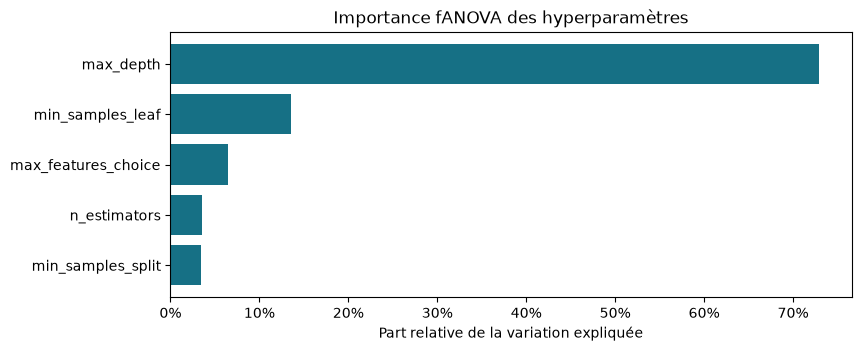

Réglage le plus influent dans cette étude : max_depth (72.9%).


In [5]:
from optuna.importance import FanovaImportanceEvaluator, get_param_importances

importance = get_param_importances(study, evaluator=FanovaImportanceEvaluator(seed=SEED))
importance_table = pd.DataFrame([
    {'Hyperparamètre': key, 'Importance relative': value}
    for key, value in importance.items()
])
display(importance_table.style.hide(axis='index').format({'Importance relative': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(8.5, 3.4), layout='constrained')
ordered = importance_table.sort_values('Importance relative')
ax.barh(ordered['Hyperparamètre'], ordered['Importance relative'], color='#167085')
ax.set(xlabel='Part relative de la variation expliquée', title='Importance fANOVA des hyperparamètres')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.show()
print(f'Réglage le plus influent dans cette étude : {importance_table.iloc[0]["Hyperparamètre"]} '
      f'({importance_table.iloc[0]["Importance relative"]:.1%}).')

## 5. Choisir les seuils sur la validation dédiée

Les hyperparamètres sont maintenant figés. Nous rechargeons réellement les modèles MLflow de la référence et du gagnant Optuna, puis nous choisissons séparément leur seuil qui maximise F2 sur la validation dédiée.

La **précision** est la part d'alertes correctes. Le **rappel** est la part des machine-heures positives détectées. Le score **F2** combine les deux en donnant davantage de poids au rappel. Aucun seuil n'est choisi sur le test.


In [6]:
def choose_threshold(target, scores):
    precision, recall, thresholds = precision_recall_curve(target, scores)
    f2 = 5 * precision[:-1] * recall[:-1] / (4 * precision[:-1] + recall[:-1] + np.finfo(float).eps)
    return float(thresholds[np.argmax(f2)])

def measure(target, scores, threshold):
    prediction = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(target, prediction, labels=[0, 1]).ravel()
    return {'AP': float(average_precision_score(target, scores)),
            'ROC_AUC': float(roc_auc_score(target, scores)),
            'precision': float(precision_score(target, prediction, zero_division=0)),
            'recall': float(recall_score(target, prediction, zero_division=0)),
            'F2': float(fbeta_score(target, prediction, beta=2, zero_division=0)),
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn), 'threshold': threshold}

models, thresholds, validation_results = {}, {}, {}
for label, result in [('Référence', baseline), ('Optuna', best)]:
    models[label] = mlflow.sklearn.load_model(result['model_uri'])
    scores = models[label].predict_proba(X['validation'])[:, 1]
    thresholds[label] = choose_threshold(y['validation'], scores)
    validation_results[label] = measure(y['validation'], scores, thresholds[label])

validation_table = pd.DataFrame(validation_results).T
display(validation_table.style.format({
    'AP': '{:.4f}', 'ROC_AUC': '{:.4f}', 'precision': '{:.2%}', 'recall': '{:.2%}',
    'F2': '{:.4f}', 'threshold': '{:.4f}', 'TP': '{:.0f}', 'FP': '{:.0f}',
    'FN': '{:.0f}', 'TN': '{:.0f}',
}))
print('MODELES_ET_SEUILS_FIGES : le test peut maintenant être évalué une seule fois.')

,AP,ROC_AUC,precision,recall,F2,TP,FP,FN,TN,threshold
Référence,0.5941,0.7597,35.85%,63.66%,0.5511,2167,3878,1237,12503,0.3299
Optuna,0.5762,0.7411,34.00%,64.89%,0.5491,2209,4288,1195,12093,0.3249


MODELES_ET_SEUILS_FIGES : le test peut maintenant être évalué une seule fois.


## 6. Comparer avant/après sur le test historique

Le test contient 20 145 machine-heures, dont 3 478 positives. L'AP et la ROC-AUC évaluent le classement sans dépendre du seuil ; précision, rappel, F2 et matrice de confusion utilisent le seuil choisi sur validation.

Le test a déjà été consulté dans les notebooks précédents. Cette comparaison reste pédagogique : une nouvelle période future est nécessaire pour une confirmation réellement indépendante.


In [7]:
test_results = {}
for label, model in models.items():
    scores = model.predict_proba(X['test'])[:, 1]
    test_results[label] = measure(y['test'], scores, thresholds[label])

test_table = pd.DataFrame(test_results).T
test_table.loc['Variation Optuna - référence'] = test_table.loc['Optuna'] - test_table.loc['Référence']
display(test_table.style.format({
    'AP': '{:+.4f}', 'ROC_AUC': '{:+.4f}', 'precision': '{:+.2%}', 'recall': '{:+.2%}',
    'F2': '{:+.4f}', 'threshold': '{:+.4f}', 'TP': '{:+.0f}', 'FP': '{:+.0f}',
    'FN': '{:+.0f}', 'TN': '{:+.0f}',
}))

ap_delta = test_results['Optuna']['AP'] - test_results['Référence']['AP']
fp_delta = test_results['Optuna']['FP'] - test_results['Référence']['FP']
tp_delta = test_results['Optuna']['TP'] - test_results['Référence']['TP']
display(Markdown(
    f'**Lecture métier :** variation AP test **{ap_delta:+.4f}** ; faux positifs **{fp_delta:+d}** ; '
    f'vrais positifs **{tp_delta:+d}**. Ces effectifs sont des machine-heures, pas des pannes distinctes.'
))
print('CONCLUSION TEST :', 'gain AP observé sur ce test historique.' if ap_delta > 0
      else 'aucun gain AP sur ce test historique.')

,AP,ROC_AUC,precision,recall,F2,TP,FP,FN,TN,threshold
Référence,+0.6151,+0.7737,+34.74%,+67.68%,+0.5689,+2354,+4423,+1124,+12244,+0.3299
Optuna,+0.6026,+0.7747,+32.23%,+68.34%,+0.5583,+2377,+4999,+1101,+11668,+0.3249
Variation Optuna - référence,-0.0125,+0.0010,-2.51%,+0.66%,-0.0106,+23,+576,-23,-576,-0.0051


**Lecture métier :** variation AP test **-0.0125** ; faux positifs **+576** ; vrais positifs **+23**. Ces effectifs sont des machine-heures, pas des pannes distinctes.

CONCLUSION TEST : aucun gain AP sur ce test historique.


### Matrices de confusion

Les lignes représentent la réalité et les colonnes la décision. Chaque case affiche le nombre de machine-heures puis son pourcentage dans la classe réelle. Les pourcentages de chaque ligne totalisent 100 %.

- **VN** : machine-heures négatives laissées sans alerte ;
- **FP** : fausses alertes ;
- **FN** : machine-heures positives manquées ;
- **VP** : machine-heures positives détectées.


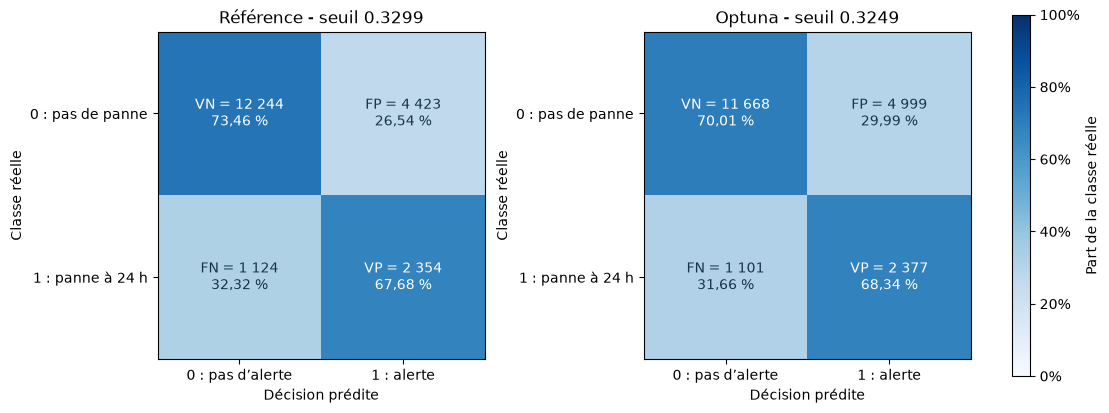

In [8]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout='constrained')
for ax, label in zip(axes, ['Référence', 'Optuna']):
    metrics = test_results[label]
    counts = np.array([[metrics['TN'], metrics['FP']], [metrics['FN'], metrics['TP']]])
    rates = counts / counts.sum(axis=1, keepdims=True)
    image = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
    names = [['VN', 'FP'], ['FN', 'VP']]
    for row in range(2):
        for col in range(2):
            annotation = f'{names[row][col]} = {counts[row, col]:,}'.replace(',', ' ')
            annotation += '\n' + f'{100 * rates[row, col]:.2f} %'.replace('.', ',')
            ax.text(col, row, annotation, ha='center', va='center', fontsize=10,
                    color='white' if rates[row, col] > .55 else '#17354A')
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['0 : pas d’alerte', '1 : alerte'],
           yticklabels=['0 : pas de panne', '1 : panne à 24 h'], xlabel='Décision prédite',
           ylabel='Classe réelle', title=f'{label} - seuil {metrics["threshold"]:.4f}')
fig.colorbar(image, ax=axes, shrink=.8, label='Part de la classe réelle', format=PercentFormatter(1))
OUTPUT_DIR = ROOT / 'outputs/optimisation-optuna'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
matrix_path = OUTPUT_DIR / 'matrices-confusion-optuna.png'
fig.savefig(matrix_path, dpi=160)
mlflow.tracking.MlflowClient().log_artifact(PARENT_ID, str(matrix_path))
plt.show()

## 7. Vérifier le surapprentissage et conclure

Trois indices sont lus ensemble : l'écart train-CV, la dispersion entre folds et la performance sur le test. Une amélioration d'un seul indicateur ne suffit pas à démontrer l'absence de surapprentissage.

La conclusion finale doit distinguer :

1. ce qu'Optuna a amélioré pendant la sélection interne ;
2. ce qui se confirme ou non sur le test historique ;
3. ce qu'il reste à valider sur une période future et au niveau des pannes distinctes.


In [9]:
elapsed = perf_counter() - campaign_started
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
fit_count = 4 + len(completed_trials) * (N_FOLDS + 1)  # référence : 3 folds + 1 refit

summary = f'''# Optimisation Indusense avec Optuna - synthèse

**Besoin.** Classer les machine-heures selon le risque de panne à 24 h. Chaque trial entraîne de nouvelles forêts ; aucune forêt existante n'est modifiée.

**Méthode.** Optuna avec TPESampler, graine {SEED}, {len(completed_trials)} trials dont {N_STARTUP_TRIALS} de démarrage, sans pruning. Trois folds chronologiques internes au train, gap de 24 h, imputation apprise dans chaque fold. Average Precision maximisée ; seuil F2 choisi sur validation ; test exclu de tout réglage.

**Gagnant.** Trial {best['trial_number']} : {best['params']}. AP CV {baseline['cv_ap']:.4f} -> {best['cv_ap']:.4f} ; écart train-CV {baseline['gap_ap']:.4f} -> {best['gap_ap']:.4f}. Hyperparamètre fANOVA principal : {importance_table.iloc[0]['Hyperparamètre']} ({importance_table.iloc[0]['Importance relative']:.1%}).

**Test.** AP {test_results['Référence']['AP']:.4f} -> {test_results['Optuna']['AP']:.4f} ({ap_delta:+.4f}) ; précision {test_results['Référence']['precision']:.2%} -> {test_results['Optuna']['precision']:.2%} ; rappel {test_results['Référence']['recall']:.2%} -> {test_results['Optuna']['recall']:.2%} ; F2 {test_results['Référence']['F2']:.4f} -> {test_results['Optuna']['F2']:.4f}. FP {test_results['Référence']['FP']} -> {test_results['Optuna']['FP']} ; FN {test_results['Référence']['FN']} -> {test_results['Optuna']['FN']}.

**Coût et limites.** {fit_count} fits et {elapsed/60:.1f} minutes pour cette exécution. Les importances dépendent de 20 trials. Le test avait déjà été consulté : confirmer sur une période future et avec des métriques par panne distincte. MLflow trace les trials, paramètres, métriques, modèles, versions et empreinte du CSV. Énergie et CO2 non mesurés.
'''

payload = {
    'parent_run_id': PARENT_ID, 'experiment_id': experiment.experiment_id,
    'study_name': STUDY_NAME, 'versions': versions, 'dataset_sha256': DATA_SHA256,
    'baseline': baseline, 'best': best, 'importance': importance_table.to_dict('records'),
    'validation': validation_results, 'test': test_results,
    'n_trials': len(completed_trials), 'n_startup_trials': N_STARTUP_TRIALS,
    'fit_count': fit_count, 'elapsed_seconds': elapsed,
    'trials': trial_table.to_dict('records'),
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_path = OUTPUT_DIR / 'resultats-optuna.json'
trials_path = OUTPUT_DIR / 'trials-optuna.csv'
results_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding='utf-8')
trial_table.to_csv(trials_path, index=False)
summary_path = ROOT / 'docs/02-sprint-2/03-suivi/04-synthese-optimisation-optuna-mlflow.md'
summary_path.write_text(summary, encoding='utf-8')

with mlflow.start_run(run_id=PARENT_ID):
    for label, metrics in test_results.items():
        prefix = 'reference' if label == 'Référence' else 'optuna'
        mlflow.log_metrics({f'test_{prefix}_{key}': value for key, value in metrics.items()})
    mlflow.log_metrics({'total_fits': fit_count, 'elapsed_seconds': elapsed})
    mlflow.log_artifact(str(results_path))
    mlflow.log_artifact(str(trials_path))
    mlflow.log_text(summary, 'synthese-optuna.md')

display(Markdown(summary))
print(f'Campagne MLflow : {PARENT_ID}')
print(f'Coût : {fit_count} fits ; {elapsed/60:.1f} minutes ; énergie non mesurée.')
print('NOTEBOOK_OPTUNA_MLFLOW_VALIDE')

# Optimisation Indusense avec Optuna - synthèse

**Besoin.** Classer les machine-heures selon le risque de panne à 24 h. Chaque trial entraîne de nouvelles forêts ; aucune forêt existante n'est modifiée.

**Méthode.** Optuna avec TPESampler, graine 42, 20 trials dont 5 de démarrage, sans pruning. Trois folds chronologiques internes au train, gap de 24 h, imputation apprise dans chaque fold. Average Precision maximisée ; seuil F2 choisi sur validation ; test exclu de tout réglage.

**Gagnant.** Trial 12 : {'n_estimators': 450, 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 2, 'max_features': 0.35}. AP CV 0.5575 -> 0.5657 ; écart train-CV 0.3563 -> 0.1712. Hyperparamètre fANOVA principal : max_depth (72.9%).

**Test.** AP 0.6151 -> 0.6026 (-0.0125) ; précision 34.74% -> 32.23% ; rappel 67.68% -> 68.34% ; F2 0.5689 -> 0.5583. FP 4423 -> 4999 ; FN 1124 -> 1101.

**Coût et limites.** 84 fits et 47.6 minutes pour cette exécution. Les importances dépendent de 20 trials. Le test avait déjà été consulté : confirmer sur une période future et avec des métriques par panne distincte. MLflow trace les trials, paramètres, métriques, modèles, versions et empreinte du CSV. Énergie et CO2 non mesurés.


Campagne MLflow : f2b7b367f3604e488883b8d8691fd909
Coût : 84 fits ; 47.6 minutes ; énergie non mesurée.
NOTEBOOK_OPTUNA_MLFLOW_VALIDE
